In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fs = 10
total_time = 1200 # seconds
n_samples = int(round(total_time * fs))

# ---------------------------
# Input definitions
# ---------------------------
lightSeq = ["RedLight", "WhiteLight", "RedLight"]
epochs_light = [0, 4*60 + 45, 10*60 + 45, 20*60]

fightSeq = ["Seperated", "Fight"]
epochs_fight = [0, 5*60 + 45, 20*60]

stimSeq = [
    "Break", "Milk", "Break", "Urine", "Break",
    "Break", "Break", "Break", "Urine", "Break",
    "Milk", "break"
]
epochDurSec = [45, 75, 30, 105, 30, 60, 60 * 5, 60 * 5, 105, 30, 75, 45]

# ---------------------------
# Initialize matrix
# ---------------------------
behavioral_matrix = {}

# ---------------------------
# 1) LIGHT CONDITIONS
# ---------------------------
unique_light = sorted(set(lightSeq))
for cond in unique_light:
    behavioral_matrix[cond] = np.zeros(n_samples, dtype=int)

for i, cond in enumerate(lightSeq):
    start_t = epochs_light[i]
    end_t = epochs_light[i + 1]

    start_s = int(round(start_t * fs))
    end_s = int(round(end_t * fs))

    start_s = max(0, min(start_s, n_samples))
    end_s = max(0, min(end_s, n_samples))

    if start_s < end_s:
        behavioral_matrix[cond][start_s:end_s] = 1

# ---------------------------
# 2) FIGHT CONDITIONS
# ---------------------------
unique_fight = sorted(set(fightSeq))
for cond in unique_fight:
    behavioral_matrix[cond] = np.zeros(n_samples, dtype=int)

for i, cond in enumerate(fightSeq):
    start_t = epochs_fight[i]
    end_t = epochs_fight[i + 1]

    start_s = int(round(start_t * fs))
    end_s = int(round(end_t * fs))

    start_s = max(0, min(start_s, n_samples))
    end_s = max(0, min(end_s, n_samples))

    if start_s < end_s:
        behavioral_matrix[cond][start_s:end_s] = 1

behavSeq = [b.capitalize() for b in stimSeq]

# remove Breaks between the two Urine epochs,
# but keep the first Break after the first Urine
urine_idx = [i for i, b in enumerate(behavSeq) if b == "Urine"]

if len(urine_idx) >= 2:
    first_break_kept = False
    for i in range(urine_idx[0] + 1, urine_idx[1]):
        if behavSeq[i] == "Break":
            if not first_break_kept:
                first_break_kept = True
            else:
                behavSeq[i] = None

# create only real behavior columns
unique_behav = sorted(set(b for b in behavSeq if b is not None))
for cond in unique_behav:
    behavioral_matrix[cond] = np.zeros(n_samples, dtype=int)

current_time = 0
for cond, dur in zip(behavSeq, epochDurSec):
    start_t = current_time
    end_t = current_time + dur

    start_s = int(round(start_t * fs))
    end_s = int(round(end_t * fs))

    start_s = max(0, min(start_s, n_samples))
    end_s = max(0, min(end_s, n_samples))

    if cond is not None and start_s < end_s:
        behavioral_matrix[cond][start_s:end_s] = 1

    current_time = end_t

# ---------------------------
# Convert to DataFrame
# ---------------------------
df_behavior = pd.DataFrame(behavioral_matrix)

print(df_behavior.head())
print(df_behavior.shape)

   RedLight  WhiteLight  Fight  Seperated  Break  Milk  Urine
0         1           0      0          1      1     0      0
1         1           0      0          1      1     0      0
2         1           0      0          1      1     0      0
3         1           0      0          1      1     0      0
4         1           0      0          1      1     0      0
(12000, 7)


In [5]:
def extract_on_periods(signal, fs):
    signal = np.asarray(signal).astype(int)
    padded = np.pad(signal, (1, 1), mode="constant", constant_values=0)
    diff = np.diff(padded)

    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]

    periods = [(start / fs, (end - start) / fs) for start, end in zip(starts, ends)]
    start_times = starts / fs
    return periods, start_times

def plot_behavioral_matrix(behavioral_matrix, fs, title="Behavioral Matrix"):
    conditions = list(behavioral_matrix.keys())

    fig, ax = plt.subplots(figsize=(14, 2))
    ax.set_facecolor("#eaeaea")

    all_start_times = []

    for i, cond in enumerate(conditions):
        periods, start_times = extract_on_periods(behavioral_matrix[cond], fs)

        ax.broken_barh(periods, (i - 0.45, 0.9), facecolors="black")
        all_start_times.extend(start_times)

    n_samples = len(next(iter(behavioral_matrix.values())))
    total_time = n_samples / fs

    # add final time explicitly
    all_start_times.append(total_time)

    # keep only unique sorted times
    all_times = np.array(sorted(set(np.round(all_start_times, 6))))

    # draw vertical lines
    for t in all_times:
        ax.axvline(t, color="gray", linewidth=0.8, alpha=0.7)

    # x ticks
    ax.set_xticks(all_times)
    ax.set_xticklabels(
        [f"{int(t//60):02d}:{int(round(t%60)):02d}" for t in all_times],
        rotation=45,
        ha="right"
    )

    ax.set_yticks(range(len(conditions)))
    ax.set_yticklabels(conditions, fontsize=9)
    ax.invert_yaxis()

    ax.set_xlim(0, total_time)

    ax.set_xlabel("Condition epoch onset (MM:SS)", fontsize=9)
    ax.set_ylabel("Paradigm conditions", fontsize=9)

    plt.tight_layout()
    plt.show()

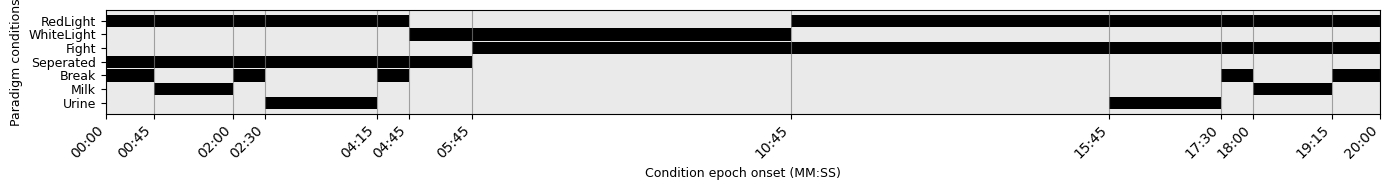

In [6]:
plot_behavioral_matrix(behavioral_matrix, fs=10)